<a href="https://colab.research.google.com/github/iamsodiq/Creep/blob/main/Charter_Axioms_on_Ishtiaq_et_al_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load and clean the NIMS Excel data**

In [44]:
# Load raw sheet exactly as in the supplementary file
import pandas as pd
df_raw= pd.read_excel(r'/content/S1.xlsx', sheet_name="Train + Test data",header=None)

In [45]:
import numpy as np

#feature selection
# Data start after the first 3 rows (0–2 are headers)
df_clean = df_raw.iloc[3:].reset_index(drop=True)

# we build a new dataframe with only the cleaned dataset

# first we make a hard-coded column indices for this specific layout
# to make our work easier in picking the relevant columns we need
# and easier to read
temp_col_idx   = 16  # "Tempertature"
stress_col_idx = 17  # "Stress"
tr_hours_idx   = 18  # "tr in hours"
tr_log_idx     = 19  # "tr in Log scale"
split_col_idx  = 20  # "Training/Testing data"

# Build a clean dataframe
df_clean["Temperature"] = pd.to_numeric(df_clean[temp_col_idx], errors="coerce")
df_clean["Stress"]      = pd.to_numeric(df_clean[stress_col_idx], errors="coerce")
df_clean["tr_hours"]    = pd.to_numeric(df_clean[tr_hours_idx], errors="coerce")
df_clean["tr_log"]      = pd.to_numeric(df_clean[tr_log_idx], errors="coerce")
df_clean["Split"]       = df_clean[split_col_idx]

df = df_clean[["Temperature", "Stress", "tr_hours", "tr_log", "Split"]] \
         .dropna(subset=["Temperature", "Stress", "tr_hours"])

# save the new, cleaned dataset
df.to_csv("creep_data_clean.csv", index=False)


**Per-temperature power-law fits (baseline)**

In [46]:
from scipy import stats

df = pd.read_csv("creep_data_clean.csv")

temps = sorted(df["Temperature"].unique())
per_temp_results = {}

for T in temps:
    df_T = df[df["Temperature"] == T]
    X = np.log10(df_T["Stress"].values)
    y = np.log10(df_T["tr_hours"].values)

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    per_temp_results[T] = (intercept, slope, r_value**2, std_err, p_value)

    print(f"\n At {T} °C:")
    print(f"  a_T = {intercept:.4f}")
    print(f"  b_T = {slope:.4f}")
    print(f"  R²  = {r_value**2:.6f}")
    print(f"  std_err = {std_err:.6f}, p = {p_value:.2e}")



 At 500.0 °C:
  a_T = 21.3227
  b_T = -8.1784
  R²  = 0.898737
  std_err = 0.340502, p = 4.94e-34

 At 550.0 °C:
  a_T = 16.5954
  b_T = -6.6084
  R²  = 0.954769
  std_err = 0.184163, p = 1.02e-42

 At 600.0 °C:
  a_T = 12.8246
  b_T = -5.2784
  R²  = 0.982243
  std_err = 0.084825, p = 5.12e-63

 At 650.0 °C:
  a_T = 10.4113
  b_T = -4.5283
  R²  = 0.969479
  std_err = 0.137794, p = 2.39e-27


**Global Arrhenius–power-law fit (all data)**

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df["TK"]        = df["Temperature"] + 273.15
df["log_stress"] = np.log10(df["Stress"])
df["log_tr"]     = np.log10(df["tr_hours"])
df["inv_TK"]     = 1.0 / df["TK"]

X_full = df[["log_stress", "inv_TK"]].values
y_full = df["log_tr"].values

model_full = LinearRegression().fit(X_full, y_full)
A = model_full.intercept_
B, C = model_full.coef_

y_pred_full = model_full.predict(X_full)
r2_full = r2_score(y_full, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_full, y_pred_full))

print("\nGlobal fit (all data):")
print(f"A = {A:.4f}, B = {B:.4f}, C = {C:.4e}")
print(f"R² = {r2_full:.6f}, RMSE = {rmse_full:.6f}")

Q_eff_kJ = C * np.log(10) * 8.314 / 1000.0
print(f"Q_eff = {Q_eff_kJ:.1f} kJ/mol")



Global fit (all data):
A = -6.7227, B = -6.1367, C = 1.8340e+04
R² = 0.904217, RMSE = 0.305047
Q_eff = 351.1 kJ/mol


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df["TK"]        = df["Temperature"] + 273.15
df["log_stress"] = np.log10(df["Stress"])
df["log_tr"]     = np.log10(df["tr_hours"])
df["inv_TK"]     = 1.0 / df["TK"]

X_full = df[["log_stress", "inv_TK"]].values
y_full = df["log_tr"].values

model_full = LinearRegression().fit(X_full, y_full)
A = model_full.intercept_
B, C = model_full.coef_

y_pred_full = model_full.predict(X_full)
r2_full = r2_score(y_full, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_full, y_pred_full))

print("\nGlobal fit (all data):")
print(f"A = {A:.4f}, B = {B:.4f}, C = {C:.4e}")
print(f"R² = {r2_full:.6f}, RMSE = {rmse_full:.6f}")

Q_eff_kJ = C * np.log(10) * 8.314 / 1000.0
print(f"Q_eff = {Q_eff_kJ:.1f} kJ/mol")



Global fit (all data):
A = -6.7227, B = -6.1367, C = 1.8340e+04
R² = 0.904217, RMSE = 0.305047
Q_eff = 351.1 kJ/mol


**Charter-style calibration / extrapolation split**

In [49]:
calibration_windows = {}
for T in temps:
    df_T = df[df["Temperature"] == T]
    s = df_T["Stress"].values
    p25, p75 = np.percentile(s, [25, 75])
    calibration_windows[T] = (p25, p75)

df["regime"] = "calibration"
for T in temps:
    p25, p75 = calibration_windows[T]
    mask_T = df["Temperature"] == T
    mask_ext = (df["Stress"] < p25) | (df["Stress"] > p75)
    df.loc[mask_T & mask_ext, "regime"] = "extrapolation"


In [22]:
# 30-70% calibartion window
calibration_windows = {}
for T in temps:
    df_T = df[df["Temperature"] == T]
    s = df_T["Stress"].values
    p30, p70 = np.percentile(s, [30, 70])
    calibration_windows[T] = (p30, p70)

df["regime"] = "calibration"
for T in temps:
    p30, p70 = calibration_windows[T]
    mask_T = df["Temperature"] == T
    mask_ext = (df["Stress"] < p30) | (df["Stress"] > p70)
    df.loc[mask_T & mask_ext, "regime"] = "extrapolation"

In [37]:
# 20-80% calibration window
calibration_windows = {}
for T in temps:
    df_T = df[df["Temperature"] == T]
    s = df_T["Stress"].values
    p20, p80 = np.percentile(s, [20, 80])
    calibration_windows[T] = (p20, p80)

df["regime"] = "calibration"
for T in temps:
    p25, p75 = calibration_windows[T]
    mask_T = df["Temperature"] == T
    mask_ext = (df["Stress"] < p20) | (df["Stress"] > p80)
    df.loc[mask_T & mask_ext, "regime"] = "extrapolation"

**Fit on calibration only, test on extrapolation**

In [52]:
df_cal = df[df["regime"] == "calibration"]
df_ext = df[df["regime"] == "extrapolation"]

X_cal = df_cal[["log_stress", "inv_TK"]].values
y_cal = df_cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A_cal = model_cal.intercept_
B_cal, C_cal = model_cal.coef_

y_pred_cal = model_cal.predict(X_cal)
r2_cal = r2_score(y_cal, y_pred_cal)
rmse_cal = np.sqrt(mean_squared_error(y_cal, y_pred_cal))

X_ext = df_ext[["log_stress", "inv_TK"]].values
y_ext = df_ext["log_tr"].values
y_pred_ext = model_cal.predict(X_ext)
r2_ext = r2_score(y_ext, y_pred_ext)
rmse_ext = np.sqrt(mean_squared_error(y_ext, y_pred_ext))

Q_eff_cal = C_cal * np.log(10) * 8.314 / 1000.0

print("\nCalibration fit:")
print(f"A = {A_cal:.4f}, B = {B_cal:.4f}, C = {C_cal:.4e}")
print(f"R²_cal = {r2_cal:.6f}, RMSE_cal = {rmse_cal:.6f}")
print("\nExtrapolation performance:")
print(f"R²_ext = {r2_ext:.6f}, RMSE_ext = {rmse_ext:.6f}")
print(f"Q_eff_cal = {Q_eff_cal:.1f} kJ/mol")



Calibration fit:
A = -6.9636, B = -6.2509, C = 1.8763e+04
R²_cal = 0.838437, RMSE_cal = 0.268706

Extrapolation performance:
R²_ext = 0.922968, RMSE_ext = 0.358867
Q_eff_cal = 359.2 kJ/mol


In [51]:
#Fit on calibration only, test on extrapolation on 20-80 split
df_cal = df[df["regime"] == "calibration"]
df_ext = df[df["regime"] == "extrapolation"]

X_cal = df_cal[["log_stress", "inv_TK"]].values
y_cal = df_cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A_cal = model_cal.intercept_
B_cal, C_cal = model_cal.coef_

y_pred_cal = model_cal.predict(X_cal)
r2_cal = r2_score(y_cal, y_pred_cal)
rmse_cal = np.sqrt(mean_squared_error(y_cal, y_pred_cal))

X_ext = df_ext[["log_stress", "inv_TK"]].values
y_ext = df_ext["log_tr"].values
y_pred_ext = model_cal.predict(X_ext)
r2_ext = r2_score(y_ext, y_pred_ext)
rmse_ext = np.sqrt(mean_squared_error(y_ext, y_pred_ext))

Q_eff_cal = C_cal * np.log(10) * 8.314 / 1000.0

print("\nCalibration fit:")
print(f"A = {A_cal:.4f}, B = {B_cal:.4f}, C = {C_cal:.4e}")
print(f"R²_cal = {r2_cal:.6f}, RMSE_cal = {rmse_cal:.6f}")
print("\nExtrapolation performance:")
print(f"R²_ext = {r2_ext:.6f}, RMSE_ext = {rmse_ext:.6f}")
print(f"Q_eff_cal = {Q_eff_cal:.1f} kJ/mol")


Calibration fit:
A = -6.9636, B = -6.2509, C = 1.8763e+04
R²_cal = 0.838437, RMSE_cal = 0.268706

Extrapolation performance:
R²_ext = 0.922968, RMSE_ext = 0.358867
Q_eff_cal = 359.2 kJ/mol


In [15]:
#Fit on calibration only, test on extrapolation on 30-70 split
df_cal = df[df["regime"] == "calibration"]
df_ext = df[df["regime"] == "extrapolation"]

X_cal = df_cal[["log_stress", "inv_TK"]].values
y_cal = df_cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A_cal = model_cal.intercept_
B_cal, C_cal = model_cal.coef_

y_pred_cal = model_cal.predict(X_cal)
r2_cal = r2_score(y_cal, y_pred_cal)
rmse_cal = np.sqrt(mean_squared_error(y_cal, y_pred_cal))

X_ext = df_ext[["log_stress", "inv_TK"]].values
y_ext = df_ext["log_tr"].values
y_pred_ext = model_cal.predict(X_ext)
r2_ext = r2_score(y_ext, y_pred_ext)
rmse_ext = np.sqrt(mean_squared_error(y_ext, y_pred_ext))

Q_eff_cal = C_cal * np.log(10) * 8.314 / 1000.0

print("\nCalibration fit:")
print(f"A = {A_cal:.4f}, B = {B_cal:.4f}, C = {C_cal:.4e}")
print(f"R²_cal = {r2_cal:.6f}, RMSE_cal = {rmse_cal:.6f}")
print("\nExtrapolation performance:")
print(f"R²_ext = {r2_ext:.6f}, RMSE_ext = {rmse_ext:.6f}")
print(f"Q_eff_cal = {Q_eff_cal:.1f} kJ/mol")


Calibration fit:
A = -6.7212, B = -6.1816, C = 1.8444e+04
R²_cal = 0.803441, RMSE_cal = 0.275903

Extrapolation performance:
R²_ext = 0.926790, RMSE_ext = 0.337396
Q_eff_cal = 353.1 kJ/mol


**Residuals and Axiom-1 checks**





In [53]:
from scipy.stats import shapiro

df["y_pred"] = model_cal.predict(df[["log_stress", "inv_TK"]].values)
df["residual"] = df["log_tr"] - df["y_pred"]

cal_res = df[df["regime"] == "calibration"]["residual"]
print("\nCalibration residuals:")
print(f"mean = {cal_res.mean():.6f}, std = {cal_res.std():.6f}, "
      f"min = {cal_res.min():.6f}, max = {cal_res.max():.6f}")

stat, p_val = shapiro(cal_res.values)
print(f"Shapiro-Wilk p = {p_val:.4f}")



Calibration residuals:
mean = -0.000000, std = 0.269685, min = -0.751015, max = 0.471082
Shapiro-Wilk p = 0.0065


**PLots**

In [54]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1) Load raw supplementary file

df_raw= pd.read_excel(r'/content/S1.xlsx', sheet_name="Train + Test data",header=None)


# 2) Drop the first 3 header rows and reset index
df_data = df_raw.iloc[3:].reset_index(drop=True)

# Column indices for this specific file layout (from the header rows)
# Row 1: steel type & composition labels
# Row 2: stress / time labels
TEMP_COL   = 16   # "Tempertature"
STRESS_COL = 17   # "Stress"
TR_H_COL   = 18   # "tr in hours"
TR_LOG_COL = 19   # "tr in Log scale"
SPLIT_COL  = 20   # "Training/Testing data"

# 3) Build a clean creep dataset
df_clean = pd.DataFrame({
    "Temperature": pd.to_numeric(df_data[TEMP_COL],   errors="coerce"),
    "Stress":      pd.to_numeric(df_data[STRESS_COL], errors="coerce"),
    "tr_hours":    pd.to_numeric(df_data[TR_H_COL],   errors="coerce"),
    "tr_log":      pd.to_numeric(df_data[TR_LOG_COL], errors="coerce"),
    "Split":       df_data[SPLIT_COL].astype(str)
})

df_clean = df_clean.dropna(subset=["Temperature", "Stress", "tr_hours"]).reset_index(drop=True)

# 4) Derived quantities
df_clean["TK"]        = df_clean["Temperature"] + 273.15
df_clean["log_stress"] = np.log10(df_clean["Stress"])
df_clean["log_tr"]     = np.log10(df_clean["tr_hours"])
df_clean["inv_TK"]     = 1.0 / df_clean["TK"]

print(df_clean.head())
print(df_clean["Temperature"].value_counts().sort_index())


   Temperature  Stress  tr_hours    tr_log          Split      TK  log_stress  \
0        500.0   216.0      54.6  1.737193  Training data  773.15    2.334454   
1        500.0   157.0    1124.2  3.050844  Training data  773.15    2.195900   
2        500.0   137.0    4132.4  3.616202  Training data  773.15    2.136721   
3        500.0   118.0   16036.6  4.205112  Training data  773.15    2.071882   
4        500.0   108.0   33230.2  4.521533  Training data  773.15    2.033424   

     log_tr    inv_TK  
0  1.737193  0.001293  
1  3.050844  0.001293  
2  3.616202  0.001293  
3  4.205112  0.001293  
4  4.521533  0.001293  
Temperature
500.0    67
550.0    63
600.0    72
650.0    36
Name: count, dtype: int64


In [8]:
# 80-20 plot
import pandas as pd
import numpy as np
from pathlib import Path

# 1) Load raw supplementary file

df_raw= pd.read_excel(r'/content/S1.xlsx', sheet_name="Train + Test data",header=None)


# 2) Drop the first 3 header rows and reset index
df_data = df_raw.iloc[3:].reset_index(drop=True)

# Column indices for this specific file layout (from the header rows)
# Row 1: steel type & composition labels
# Row 2: stress / time labels
TEMP_COL   = 16   # "Tempertature"
STRESS_COL = 17   # "Stress"
TR_H_COL   = 18   # "tr in hours"
TR_LOG_COL = 19   # "tr in Log scale"
SPLIT_COL  = 20   # "Training/Testing data"

# 3) Build a clean creep dataset
df_clean = pd.DataFrame({
    "Temperature": pd.to_numeric(df_data[TEMP_COL],   errors="coerce"),
    "Stress":      pd.to_numeric(df_data[STRESS_COL], errors="coerce"),
    "tr_hours":    pd.to_numeric(df_data[TR_H_COL],   errors="coerce"),
    "tr_log":      pd.to_numeric(df_data[TR_LOG_COL], errors="coerce"),
    "Split":       df_data[SPLIT_COL].astype(str)
})

df_clean = df_clean.dropna(subset=["Temperature", "Stress", "tr_hours"]).reset_index(drop=True)

# 4) Derived quantities
df_clean["TK"]        = df_clean["Temperature"] + 273.15
df_clean["log_stress"] = np.log10(df_clean["Stress"])
df_clean["log_tr"]     = np.log10(df_clean["tr_hours"])
df_clean["inv_TK"]     = 1.0 / df_clean["TK"]

print(df_clean.head())
print(df_clean["Temperature"].value_counts().sort_index())


   Temperature  Stress  tr_hours    tr_log          Split      TK  log_stress  \
0        500.0   216.0      54.6  1.737193  Training data  773.15    2.334454   
1        500.0   157.0    1124.2  3.050844  Training data  773.15    2.195900   
2        500.0   137.0    4132.4  3.616202  Training data  773.15    2.136721   
3        500.0   118.0   16036.6  4.205112  Training data  773.15    2.071882   
4        500.0   108.0   33230.2  4.521533  Training data  773.15    2.033424   

     log_tr    inv_TK  
0  1.737193  0.001293  
1  3.050844  0.001293  
2  3.616202  0.001293  
3  4.205112  0.001293  
4  4.521533  0.001293  
Temperature
500.0    67
550.0    63
600.0    72
650.0    36
Name: count, dtype: int64


**Per-temperature log-log stress-life plots
These replace the problematic “direct relationship” with correct negative slopes.**

500 °C: log10(tr) = 21.323 + -8.178 * log10(σ) (R²=0.899)


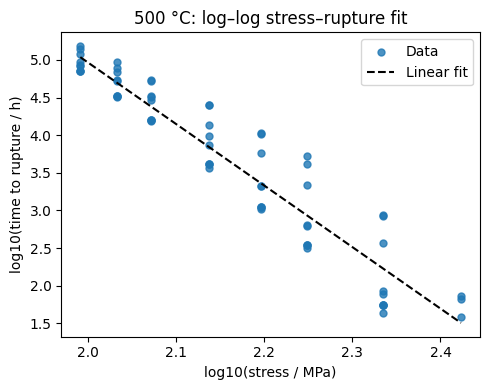

550 °C: log10(tr) = 16.595 + -6.608 * log10(σ) (R²=0.955)


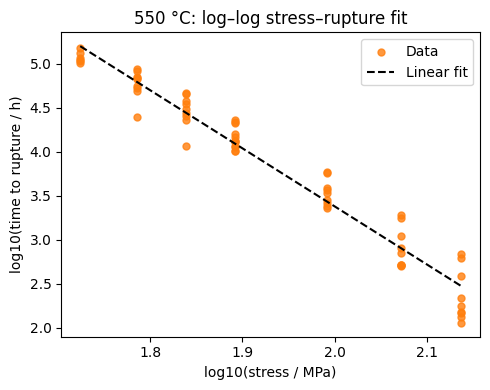

600 °C: log10(tr) = 12.825 + -5.278 * log10(σ) (R²=0.982)


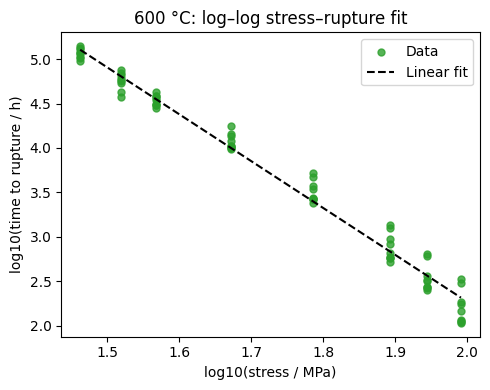

650 °C: log10(tr) = 10.411 + -4.528 * log10(σ) (R²=0.969)


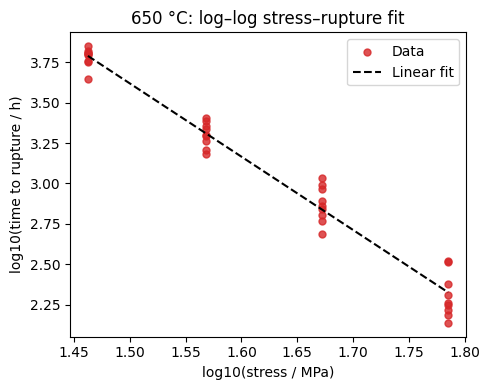

In [55]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

temps = sorted(df_clean["Temperature"].unique())
colors_T = {500.0: "tab:blue", 550.0: "tab:orange",
            600.0: "tab:green", 650.0: "tab:red"}

for T in temps:
    df_T = df_clean[df_clean["Temperature"] == T]
    X = df_T[["log_stress"]].values
    y = df_T["log_tr"].values

    model_T = LinearRegression().fit(X, y)
    y_pred  = model_T.predict(X)
    r2      = r2_score(y, y_pred)
    slope   = model_T.coef_[0]
    intercept = model_T.intercept_

    print(f"{int(T)} °C: log10(tr) = {intercept:.3f} + {slope:.3f} * log10(σ) "
          f"(R²={r2:.3f})")

    # Plot
    plt.figure(figsize=(5,4))
    plt.scatter(df_T["log_stress"], df_T["log_tr"],
                s=25, color=colors_T[T], alpha=0.8, label="Data")
    xs = np.linspace(df_T["log_stress"].min(), df_T["log_stress"].max(), 100)
    ys = model_T.predict(xs.reshape(-1,1))
    plt.plot(xs, ys, "k--", label="Linear fit")

    plt.xlabel("log10(stress / MPa)")
    plt.ylabel("log10(time to rupture / h)")
    plt.title(f"{int(T)} °C: log–log stress–rupture fit")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"fig_loglog_stress_life_{int(T)}C.png", dpi=300)
    plt.show()
    plt.close()


**Define Charter‑style calibration / extrapolation split**

In [56]:
# Charter-style mid-stress calibration window (25–75th percentile per T)
calibration_windows = {}
for T in temps:
    sT = df_clean.loc[df_clean["Temperature"] == T, "Stress"]
    p25, p75 = np.percentile(sT, [25, 75])
    calibration_windows[T] = (p25, p75)
    print(f"{int(T)} °C: calib window {p25:.1f}–{p75:.1f} MPa "
          f"(full {sT.min():.1f}–{sT.max():.1f})")

regime = []
for _, row in df_clean.iterrows():
    T = row["Temperature"]
    s = row["Stress"]
    p25, p75 = calibration_windows[T]
    if (s < p25) or (s > p75):
        regime.append("extrapolation")
    else:
        regime.append("calibration")

df_clean["regime"] = regime
print(df_clean["regime"].value_counts())


500 °C: calib window 108.0–177.0 MPa (full 98.0–265.0)
550 °C: calib window 69.0–118.0 MPa (full 53.0–137.0)
600 °C: calib window 36.0–80.5 MPa (full 29.0–98.0)
650 °C: calib window 35.0–50.5 MPa (full 29.0–61.0)
regime
calibration      138
extrapolation    100
Name: count, dtype: int64


In [25]:
#30-70
# Charter-style mid-stress calibration window (25–75th percentile per T)
calibration_windows = {}
# Changed iloc[3:] to iloc[4:] to skip the blank row in the Excel file
df_data = df_raw.iloc[4:].reset_index(drop=True)

# Column indices for this specific file layout (from the header rows)
# Row 1: steel type & composition labels
# Row 2: stress / time labels
TEMP_COL   = 16   # "Tempertature"
STRESS_COL = 17   # "Stress"
TR_H_COL   = 18   # "tr in hours"
TR_LOG_COL = 19   # "tr in Log scale"
SPLIT_COL  = 20   # "Training/Testing data"

# 3) Build a clean creep dataset
df_clean = pd.DataFrame({
    "Temperature": pd.to_numeric(df_data[TEMP_COL],   errors="coerce"),
    "Stress":      pd.to_numeric(df_data[STRESS_COL], errors="coerce"),
    "tr_hours":    pd.to_numeric(df_data[TR_H_COL],   errors="coerce"),
    "tr_log":      pd.to_numeric(df_data[TR_LOG_COL], errors="coerce"),
    "Split":       df_data[SPLIT_COL].astype(str)
})

df_clean = df_clean.dropna(subset=["Temperature", "Stress", "tr_hours"]).reset_index(drop=True)

# 4) Derived quantities
df_clean["TK"]        = df_clean["Temperature"] + 273.15
df_clean["log_stress"] = np.log10(df_clean["Stress"])
df_clean["log_tr"]     = np.log10(df_clean["tr_hours"])
df_clean["inv_TK"]     = 1.0 / df_clean["TK"]

temps = sorted(df_clean["Temperature"].unique())

for T in temps:
    sT = df_clean.loc[df_clean["Temperature"] == T, "Stress"]
    p30, p70 = np.percentile(sT, [30, 70])
    calibration_windows[T] = (p30, p70)
    print(f"{int(T)} °C: calib window {p30:.1f}–{p70:.1f} MPa "
          f"(full {sT.min():.1f}–{sT.max():.1f})")

regime = []
for _, row in df_clean.iterrows():
    T = row["Temperature"]
    s = row["Stress"]
    p30, p70 = calibration_windows[T]
    if (s < p30) or (s > p70):
        regime.append("extrapolation")
    else:
        regime.append("calibration")

df_clean["regime"] = regime
print(df_clean["regime"].value_counts())

500 °C: calib window 118.0–177.0 MPa (full 98.0–265.0)
550 °C: calib window 69.0–98.0 MPa (full 53.0–137.0)
600 °C: calib window 37.0–78.0 MPa (full 29.0–98.0)
650 °C: calib window 37.0–47.0 MPa (full 29.0–61.0)
regime
calibration      120
extrapolation    118
Name: count, dtype: int64


In [41]:
#30-70
# Charter-style mid-stress calibration window (25–75th percentile per T)
calibration_windows = {}
# Changed iloc[3:] to iloc[4:] to skip the blank row in the Excel file
df_data = df_raw.iloc[4:].reset_index(drop=True)

# Column indices for this specific file layout (from the header rows)
# Row 1: steel type & composition labels
# Row 2: stress / time labels
TEMP_COL   = 16   # "Tempertature"
STRESS_COL = 17   # "Stress"
TR_H_COL   = 18   # "tr in hours"
TR_LOG_COL = 19   # "tr in Log scale"
SPLIT_COL  = 20   # "Training/Testing data"

# 3) Build a clean creep dataset
df_clean = pd.DataFrame({
    "Temperature": pd.to_numeric(df_data[TEMP_COL],   errors="coerce"),
    "Stress":      pd.to_numeric(df_data[STRESS_COL], errors="coerce"),
    "tr_hours":    pd.to_numeric(df_data[TR_H_COL],   errors="coerce"),
    "tr_log":      pd.to_numeric(df_data[TR_LOG_COL], errors="coerce"),
    "Split":       df_data[SPLIT_COL].astype(str)
})

df_clean = df_clean.dropna(subset=["Temperature", "Stress", "tr_hours"]).reset_index(drop=True)

# 4) Derived quantities
df_clean["TK"]        = df_clean["Temperature"] + 273.15
df_clean["log_stress"] = np.log10(df_clean["Stress"])
df_clean["log_tr"]     = np.log10(df_clean["tr_hours"])
df_clean["inv_TK"]     = 1.0 / df_clean["TK"]

temps = sorted(df_clean["Temperature"].unique())

for T in temps:
    sT = df_clean.loc[df_clean["Temperature"] == T, "Stress"]
    p20, p80 = np.percentile(sT, [20, 80])
    calibration_windows[T] = (p20, p80)
    print(f"{int(T)} °C: calib window {p20:.1f}–{p80:.1f} MPa "
          f"(full {sT.min():.1f}–{sT.max():.1f})")

regime = []
for _, row in df_clean.iterrows():
    T = row["Temperature"]
    s = row["Stress"]
    p30, p70 = calibration_windows[T]
    if (s < p20) or (s > p80):
        regime.append("extrapolation")
    else:
        regime.append("calibration")

df_clean["regime"] = regime
print(df_clean["regime"].value_counts())

500 °C: calib window 108.0–177.0 MPa (full 98.0–265.0)
550 °C: calib window 61.0–118.0 MPa (full 53.0–137.0)
600 °C: calib window 33.0–88.0 MPa (full 29.0–98.0)
650 °C: calib window 29.0–61.0 MPa (full 29.0–61.0)
regime
extrapolation    142
calibration       96
Name: count, dtype: int64


**Fit global Arrhenius-power law on calibration only**

In [58]:
from sklearn.metrics import mean_squared_error

cal = df_clean[df_clean["regime"] == "calibration"]
ext = df_clean[df_clean["regime"] == "extrapolation"]

X_cal = cal[["log_stress", "inv_TK"]].values
y_cal = cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A = model_cal.intercept_
B, C = model_cal.coef_

y_cal_pred = model_cal.predict(X_cal)
r2_cal  = r2_score(y_cal, y_cal_pred)
rmse_cal = np.sqrt(mean_squared_error(y_cal, y_cal_pred))

X_ext = ext[["log_stress", "inv_TK"]].values
y_ext = ext["log_tr"].values
y_ext_pred = model_cal.predict(X_ext)
r2_ext  = r2_score(y_ext, y_ext_pred)
rmse_ext = np.sqrt(mean_squared_error(y_ext, y_ext_pred))

Q_eff_kJ = C * np.log(10) * 8.314 / 1000.0

print("\nGlobal Arrhenius–power law (calibration only):")
print(f"log10(tr) = {A:.4f} + {B:.4f} * log10(σ) + {C:.4e} * (1/T_K)")
print(f"R²_cal = {r2_cal:.4f}, RMSE_cal = {rmse_cal:.4f} log10 units")
print(f"R²_ext = {r2_ext:.4f}, RMSE_ext = {rmse_ext:.4f} log10 units")
print(f"Stress exponent |B| = {abs(B):.2f}")
print(f"Q_eff = {Q_eff_kJ:.1f} kJ/mol")



Global Arrhenius–power law (calibration only):
log10(tr) = -6.9636 + -6.2509 * log10(σ) + 1.8763e+04 * (1/T_K)
R²_cal = 0.8384, RMSE_cal = 0.2687 log10 units
R²_ext = 0.9230, RMSE_ext = 0.3589 log10 units
Stress exponent |B| = 6.25
Q_eff = 359.2 kJ/mol


In [ ]:
#30-70
from sklearn.metrics import mean_squared_error

cal = df_clean[df_clean["regime"] == "calibration"]
ext = df_clean[df_clean["regime"] == "extrapolation"]

X_cal = cal[["log_stress", "inv_TK"]].values
y_cal = cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A = model_cal.intercept_
B, C = model_cal.coef_

y_cal_pred = model_cal.predict(X_cal)
r2_cal  = r2_score(y_cal, y_cal_pred)
rmse_cal = np.sqrt(mean_squared_error(y_cal, y_cal_pred))

X_ext = ext[["log_stress", "inv_TK"]].values
y_ext = ext["log_tr"].values
y_ext_pred = model_cal.predict(X_ext)
r2_ext  = r2_score(y_ext, y_ext_pred)
rmse_ext = np.sqrt(mean_squared_error(y_ext, y_ext_pred))

Q_eff_kJ = C * np.log(10) * 8.314 / 1000.0

print("\nGlobal Arrhenius–power law (calibration only):")
print(f"log10(tr) = {A:.4f} + {B:.4f} * log10(σ) + {C:.4e} * (1/T_K)")
print(f"R²_cal = {r2_cal:.4f}, RMSE_cal = {rmse_cal:.4f} log10 units")
print(f"R²_ext = {r2_ext:.4f}, RMSE_ext = {rmse_ext:.4f} log10 units")
print(f"Stress exponent |B| = {abs(B):.2f}")
print(f"Q_eff = {Q_eff_kJ:.1f} kJ/mol")

In [42]:
#20-80
from sklearn.metrics import mean_squared_error

cal = df_clean[df_clean["regime"] == "calibration"]
ext = df_clean[df_clean["regime"] == "extrapolation"]

X_cal = cal[["log_stress", "inv_TK"]].values
y_cal = cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A = model_cal.intercept_
B, C = model_cal.coef_

y_cal_pred = model_cal.predict(X_cal)
r2_cal  = r2_score(y_cal, y_cal_pred)
rmse_cal = np.sqrt(mean_squared_error(y_cal, y_cal_pred))

X_ext = ext[["log_stress", "inv_TK"]].values
y_ext = ext["log_tr"].values
y_ext_pred = model_cal.predict(X_ext)
r2_ext  = r2_score(y_ext, y_ext_pred)
rmse_ext = np.sqrt(mean_squared_error(y_ext, y_ext_pred))

Q_eff_kJ = C * np.log(10) * 8.314 / 1000.0

print("\nGlobal Arrhenius–power law (calibration only):")
print(f"log10(tr) = {A:.4f} + {B:.4f} * log10(σ) + {C:.4e} * (1/T_K)")
print(f"R²_cal = {r2_cal:.4f}, RMSE_cal = {rmse_cal:.4f} log10 units")
print(f"R²_ext = {r2_ext:.4f}, RMSE_ext = {rmse_ext:.4f} log10 units")
print(f"Stress exponent |B| = {abs(B):.2f}")
print(f"Q_eff = {Q_eff_kJ:.1f} kJ/mol")


Global Arrhenius–power law (calibration only):
log10(tr) = -9.8499 + -4.7377 * log10(σ) + 1.9034e+04 * (1/T_K)
R²_cal = 0.9869, RMSE_cal = 0.1015 log10 units
R²_ext = 0.3788, RMSE_ext = 0.7752 log10 units
Stress exponent |B| = 4.74
Q_eff = 364.4 kJ/mol


** Global model TTS plot (all temperatures)**

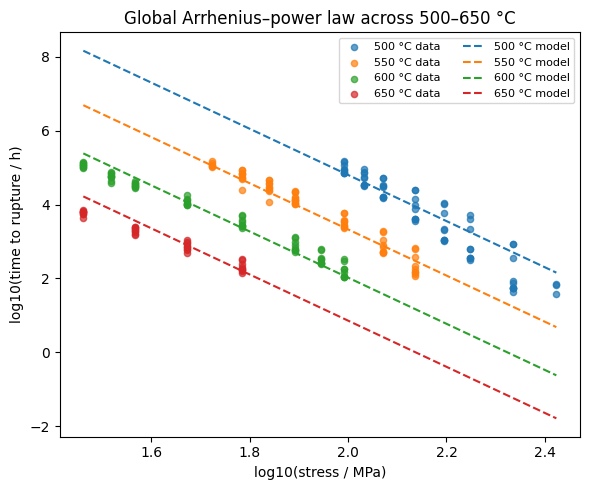

In [59]:
df_clean["y_pred"]   = model_cal.predict(df_clean[["log_stress","inv_TK"]].values)
df_clean["residual"] = df_clean["log_tr"] - df_clean["y_pred"]

plt.figure(figsize=(6,5))
for T in temps:
    mask = df_clean["Temperature"] == T
    plt.scatter(df_clean.loc[mask, "log_stress"],
                df_clean.loc[mask, "log_tr"],
                s=20, alpha=0.7, label=f"{int(T)} °C data",
                color=colors_T[T])

# For each T, overplot model line
for T in temps:
    TK = T + 273.15
    xs = np.linspace(df_clean["log_stress"].min(), df_clean["log_stress"].max(), 100)
    inv_TK = np.full_like(xs, 1.0 / TK)
    X_line = np.column_stack([xs, inv_TK])
    ys = model_cal.predict(X_line)
    plt.plot(xs, ys, linestyle="--", color=colors_T[T], label=f"{int(T)} °C model")

plt.xlabel("log10(stress / MPa)")
plt.ylabel("log10(time to rupture / h)")
plt.title("Global Arrhenius–power law across 500–650 °C")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("fig_global_TTS_loglog.png", dpi=300)
plt.show()
plt.close()


**Residual plots (Charter Axiom 1 & extrapolation)**

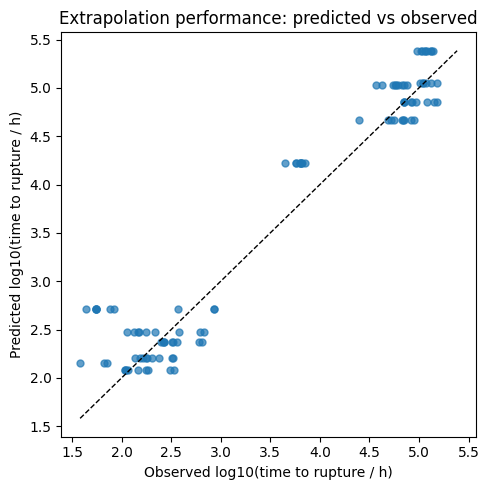

In [60]:
# Residuals vs stress, coloured by regime
plt.figure(figsize=(6,4))
for reg, marker, col in [("calibration","o","tab:blue"),
                         ("extrapolation","s","tab:red")]:
    mask = df_clean["regime"] == reg
    plt.scatter(df_clean.loc[mask,"Stress"],
                df_clean.loc[mask,"residual"],
                marker=marker, s=25, alpha=0.7,
                label=reg, color=col)
plt.axhline(0.0, color="k", linewidth=1)
plt.xlabel("Stress / MPa")
plt.ylabel("Residual in log10(time)")
plt.title("Residuals vs stress (calibration vs extrapolation)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_residuals_vs_stress.png", dpi=300)
plt.close()

# Predicted vs observed for extrapolation points
plt.figure(figsize=(5,5))
plt.scatter(ext["log_tr"], y_ext_pred, s=25, alpha=0.7)
mn = min(ext["log_tr"].min(), y_ext_pred.min())
mx = max(ext["log_tr"].max(), y_ext_pred.max())
plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
plt.xlabel("Observed log10(time to rupture / h)")
plt.ylabel("Predicted log10(time to rupture / h)")
plt.title("Extrapolation performance: predicted vs observed")
plt.tight_layout()
plt.savefig("fig_pred_vs_obs_extrapolation.png", dpi=300)
plt.show()
plt.close()


Note with plots


**Imports and data loading**

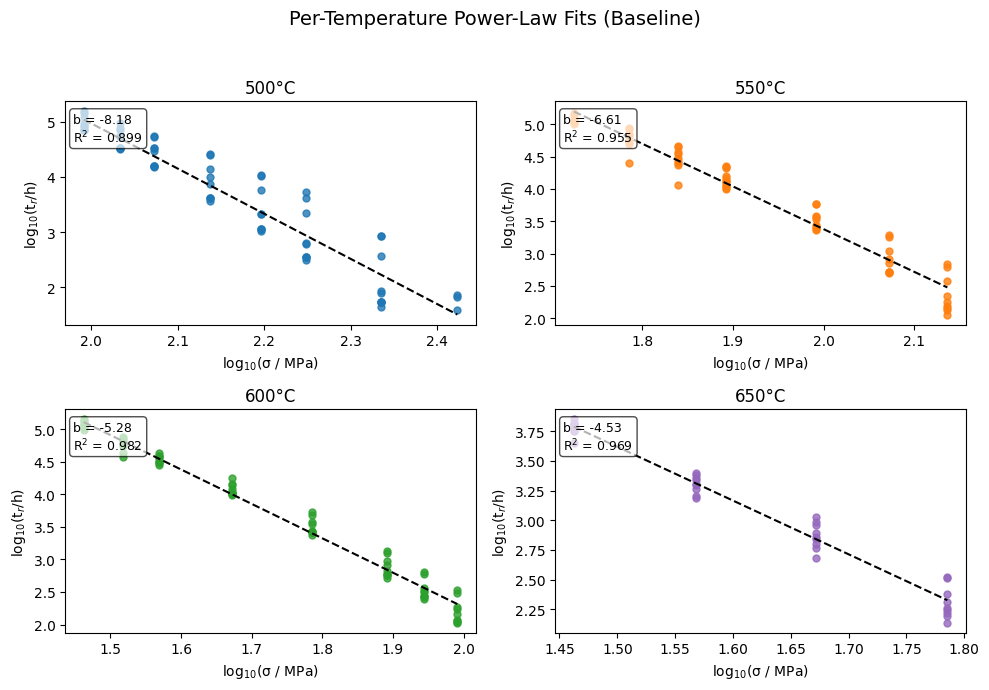

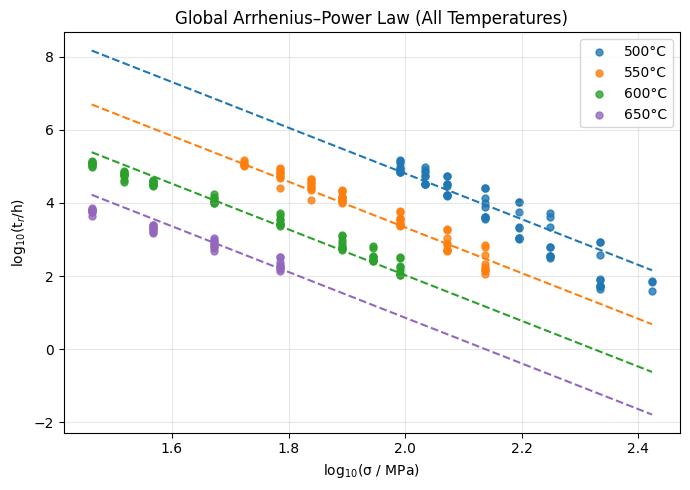

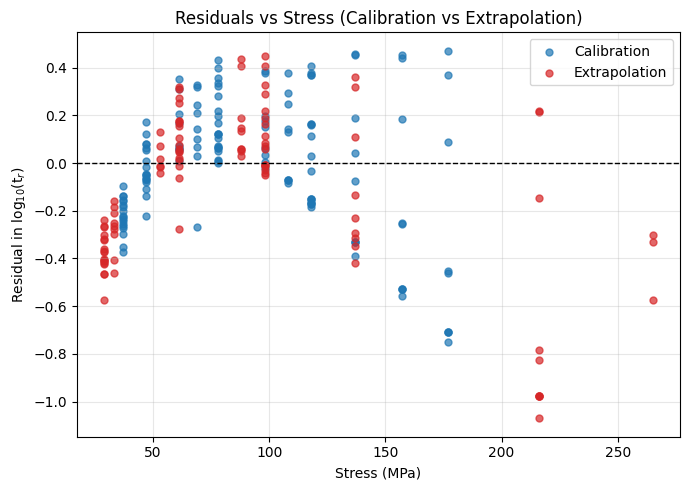

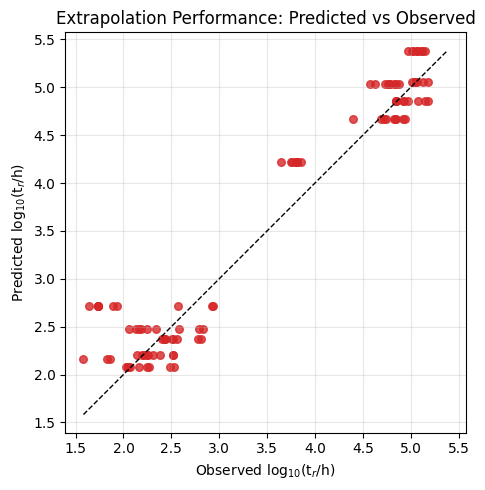

Saved figures: fig1_per_temp_fits.png, fig2_global_law.png, fig3_residuals.png, fig4_pred_vs_obs.png


In [61]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Loading& preparing the data

df_raw= pd.read_excel(r'/content/S1.xlsx',
                      sheet_name="Train + Test data",header=None)

df_clean = df_raw.iloc[3:].reset_index(drop=True)

TEMP_COL = 16
STRESS_COL = 17
TR_H_COL = 18
TR_LOG_COL = 19
SPLIT_COL = 20

df = pd.DataFrame({
    "Temperature": pd.to_numeric(df_clean[TEMP_COL], errors="coerce"),
    "Stress":      pd.to_numeric(df_clean[STRESS_COL], errors="coerce"),
    "tr_hours":    pd.to_numeric(df_clean[TR_H_COL], errors="coerce"),
    "tr_log":      pd.to_numeric(df_clean[TR_LOG_COL], errors="coerce"),
    "Split":       df_clean[SPLIT_COL].astype(str)
}).dropna(subset=["Temperature", "Stress", "tr_hours"]).reset_index(drop=True)

df["TK"]         = df["Temperature"] + 273.15
df["log_stress"] = np.log10(df["Stress"])
df["log_tr"]     = np.log10(df["tr_hours"])
df["inv_TK"]     = 1.0 / df["TK"]

temps = sorted(df["Temperature"].unique())
color_map = {500.0: "tab:blue", 550.0: "tab:orange",
             600.0: "tab:green", 650.0: "tab:purple"}


# FIGURE 1 – Per-temperature log–log fits

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)
axes = axes.ravel()

for ax, T in zip(axes, temps):
    df_T = df[df["Temperature"] == T]
    X = df_T["log_stress"].values
    Y = df_T["log_tr"].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

    # scatter
    ax.scatter(X, Y, s=25, color=color_map[T], alpha=0.8)

    # fit line
    xs = np.linspace(X.min(), X.max(), 100)
    ys = intercept + slope * xs
    ax.plot(xs, ys, "k--", linewidth=1.5)

    ax.set_title(f"{int(T)}°C")
    ax.set_xlabel("log$_{10}$(σ / MPa)")
    ax.set_ylabel("log$_{10}$(t$_r$/h)")
    ax.text(0.02, 0.95,
            f"b = {slope:.2f}\nR$^2$ = {r_value**2:.3f}",
            transform=ax.transAxes,
            va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle("Per-Temperature Power-Law Fits (Baseline)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("fig1_per_temp_fits.png", dpi=300)
plt.show()
plt.close(fig)


# 1. Define calibration/extrapolation and fit global law

calibration_windows = {}
for T in temps:
    sT = df.loc[df["Temperature"] == T, "Stress"]
    p25, p75 = np.percentile(sT, [25, 75])
    calibration_windows[T] = (p25, p75)

regime = []
for _, row in df.iterrows():
    T = row["Temperature"]
    s = row["Stress"]
    p25, p75 = calibration_windows[T]
    regime.append("extrapolation" if (s < p25 or s > p75) else "calibration")
df["regime"] = regime

df_cal = df[df["regime"] == "calibration"]
df_ext = df[df["regime"] == "extrapolation"]

X_cal = df_cal[["log_stress", "inv_TK"]].values
y_cal = df_cal["log_tr"].values

model_cal = LinearRegression().fit(X_cal, y_cal)
A_cal = model_cal.intercept_
B_cal, C_cal = model_cal.coef_

df["y_pred"] = model_cal.predict(df[["log_stress", "inv_TK"]].values)
df["residual"] = df["log_tr"] - df["y_pred"]

# FIGURE 2 – Global Arrhenius–power law

fig, ax = plt.subplots(figsize=(7, 5))

for T in temps:
    df_T = df[df["Temperature"] == T]
    ax.scatter(df_T["log_stress"], df_T["log_tr"],
               s=25, color=color_map[T], alpha=0.8, label=f"{int(T)}°C")

    # model line at that T
    TK = T + 273.15
    xs = np.linspace(df["log_stress"].min(), df["log_stress"].max(), 100)
    ys = A_cal + B_cal * xs + C_cal / TK
    ax.plot(xs, ys, linestyle="--", color=color_map[T])

ax.set_xlabel("log$_{10}$(σ / MPa)")
ax.set_ylabel("log$_{10}$(t$_r$/h)")
ax.set_title("Global Arrhenius–Power Law (All Temperatures)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("fig2_global_law.png", dpi=300)
plt.show()
plt.close(fig)


# FIGURE 3 – Residuals vs stress (Cal/Extrap)

fig, ax = plt.subplots(figsize=(7, 5))

df_cal_plot = df[df["regime"] == "calibration"]
df_ext_plot = df[df["regime"] == "extrapolation"]

ax.scatter(df_cal_plot["Stress"], df_cal_plot["residual"],
           s=25, color="tab:blue", alpha=0.7, label="Calibration")
ax.scatter(df_ext_plot["Stress"], df_ext_plot["residual"],
           s=25, color="tab:red", alpha=0.7, label="Extrapolation")

ax.axhline(0.0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Stress (MPa)")
ax.set_ylabel("Residual in log$_{10}$(t$_r$)")
ax.set_title("Residuals vs Stress (Calibration vs Extrapolation)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("fig3_residuals.png", dpi=300)
plt.show()
plt.close(fig)


# FIGURE 4 – Predicted vs observed (extrap)

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(df_ext_plot["log_tr"], df_ext_plot["y_pred"],
           s=30, color="tab:red", alpha=0.8)

mn = min(df_ext_plot["log_tr"].min(), df_ext_plot["y_pred"].min())
mx = max(df_ext_plot["log_tr"].max(), df_ext_plot["y_pred"].max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)

ax.set_xlabel("Observed log$_{10}$(t$_r$/h)")
ax.set_ylabel("Predicted log$_{10}$(t$_r$/h)")
ax.set_title("Extrapolation Performance: Predicted vs Observed")
ax.grid(alpha=0.3)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig("fig4_pred_vs_obs.png", dpi=300)
plt.show()
plt.close(fig)

print("Saved figures:",
      "fig1_per_temp_fits.png, fig2_global_law.png, fig3_residuals.png, fig4_pred_vs_obs.png")

**Figure 1 - Per-temperature power-law fits**

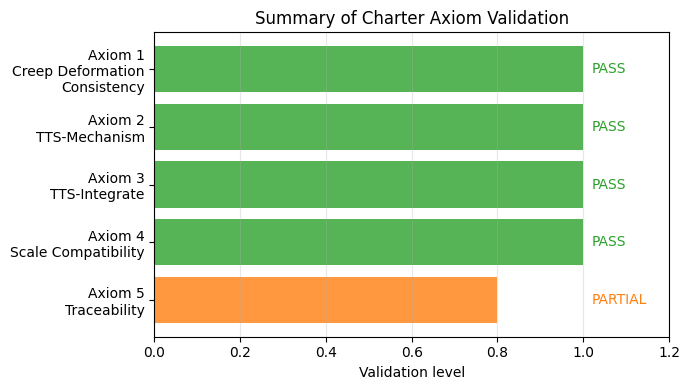

Also saved: fig5_charter_summary.png


In [62]:

# FIGURE 5 – Charter axiom summary
axioms = [
    "Axiom 1\nCreep Deformation\nConsistency",
    "Axiom 2\nTTS-Mechanism",
    "Axiom 3\nTTS-Integrate",
    "Axiom 4\nScale Compatibility",
    "Axiom 5\nTraceability"
]

status = ["PASS", "PASS", "PASS", "PASS", "PARTIAL"]
values = [1, 1, 1, 1, 0.8]  # shorter bar for partial
colors = ["tab:green", "tab:green", "tab:green", "tab:green", "tab:orange"]

fig, ax = plt.subplots(figsize=(7, 4))

y_pos = np.arange(len(axioms))
ax.barh(y_pos, values, color=colors, alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(axioms)
ax.set_xlim(0, 1.2)
ax.set_xlabel("Validation level")
ax.set_title("Summary of Charter Axiom Validation")

# Put PASS / PARTIAL labels on the right of each bar
for i, (v, s, c) in enumerate(zip(values, status, colors)):
    ax.text(1.02, i, s, va="center", ha="left", color=c, fontsize=10)

ax.invert_yaxis()  # Axiom 1 on top
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig("fig5_charter_summary.png", dpi=300)
plt.show()
plt.close(fig)

print("Also saved: fig5_charter_summary.png")
